### Instalando Bibliotecas

In [ ]:
!pip install --upgrade ase numpy==2.0 -q
!pip install git+https://github.com/imagdau/aseMolec@f411b5618381ba3b807cbbb041f12f460a69d606 -q
!pip install mace-torch cuequivariance cuequivariance-torch cuequivariance-ops-torch-cu12 torch-dftd -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 94.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.7/266.7 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.8/216.8 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.3/406.3 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.7/681.7 kB 35.7 MB/s eta 0:0

In [ ]:
!pip uninstall -y ase
!pip install git+https://gitlab.com/ase/ase.git

Found existing installation: ase 3.26.0
Uninstalling ase-3.26.0:
  Successfully uninstalled ase-3.26.0
  Cloning https://gitlab.com/ase/ase.git to /tmp/pip-req-build-d423n8gb
  Running command git clone --filter=blob:none --quiet https://gitlab.com/ase/ase.git /tmp/pip-req-build-d423n8gb
  Resolved https://gitlab.com/ase/ase.git to commit 83a843b3b3daf36127684ed08aa6a5b1d3e4c46e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ase: filename=ase-3.27.0b1-py3-none-any.whl size=2843415 sha256=170a3eff339aab4c38209e581acaeb539bb5eeb80fe08c31126836b32b76d258
  Stored in directory: /tmp/pip-ephem-wheel-cache-zzmwcaog/wheels/1c/7d/73/24ac65b73c63573b45901f9e03cce115dafd5e46f4ad31c986
Successfully built ase


In [ ]:
!pip install rdfpy


### Simulando AIMD de longa duração via mace

In [ ]:
import os
from ase.io import write, read
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
np.random.seed(701) #fazendo com que os resultados sejam reprodutíveis

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.calc = calc

    #initialize the temperature

    MaxwellBoltzmannDistribution(init_conf, temperature_K=260) #initialize temperature at 300
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 0.5*units.fs, temperature_K=temp, friction=0.005/units.fs) #drive system to desired temperature

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    os.system('rm -rfv '+fname)

    fig, ax = plt.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
            dyn.atoms.info['energy_mace'] = dyn.atoms.get_potential_energy()
            dyn.atoms.arrays['forces_mace'] = dyn.atoms.calc.get_forces()
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

            ax[0].plot(np.array(time_fs), np.array(energies), color="b")
            ax[0].set_ylabel('E (eV/atom)')

            # plot the temperature of the system as subplots
            ax[1].plot(np.array(time_fs), temperature, color="r")
            ax[1].set_ylabel('T (K)')
            ax[1].set_xlabel('Time (fs)')

            display.clear_output(wait=True)
            display.display(plt.gcf())
            time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

In [ ]:
from mace.calculators import mace_mp

macemp = mace_mp(model="small", dispersion=True, default_dtype = "float32", device="cuda")

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Cached MACE model to /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Using TorchDFTD3Calculator for D3 dispersion corrections


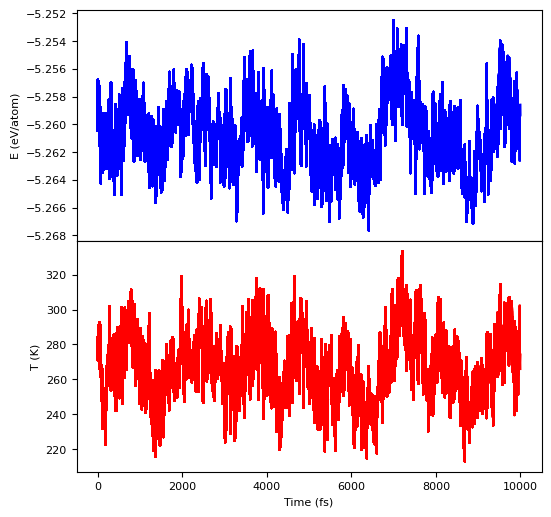

MD finished in 231.44 minutes!
Tempo de execução:  3.858107234173351 horas


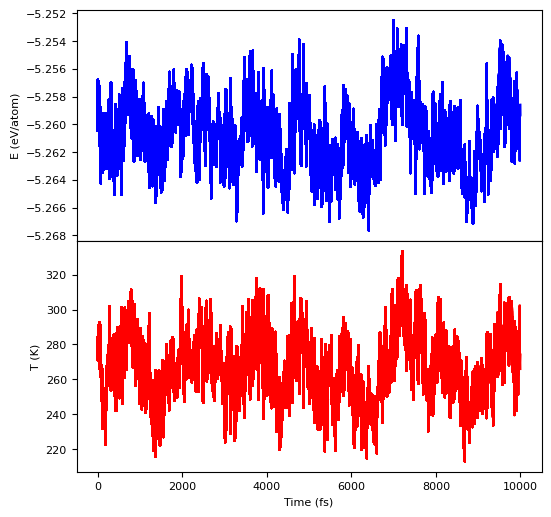

In [ ]:
import os
import time
from ase.io import read

t1 = time.time()

# #======== carrega apenas o último frame ========
# init_conf = read("mace_md_sI_CO2_260-K.xyz", index=-1)
# print(ultimo_frame)

#======== carrega todos os frames e seleciona apenas o último ========
frames = read("mace_md_sI_CO2_260-K.xyz", index=":")
init_conf = frames[-1]
init_conf.set_constraint([]) # Limpa todos os vínculos

os.makedirs('/content/drive/MyDrive/mace_MD', exist_ok=True)

simpleMD(init_conf, temp=260, calc=macemp, fname='/content/drive/MyDrive/mace_MD/producao_mace_md_sI_CO2_260-K.xyz', s=10, T=20000)
t2 = time.time()
print('Tempo de execução: ', (t2-t1)/3600, 'horas')
